# Airbnb Price Intelligence for NYC Listings
I had done a project for AMS 317 (Linear Regression Analysis) where my group and I looked into 2019 AirBnb dataset for New York City. We had done a complete data analysis, EDA, used ANOVA to measure the question "Does different types of rooms vs the number of reviews".

I wanted to do a similar analysis on Airbnb dataset but on a better idea. Instead of just conducting an analysis and ANOVA. I wanted to build a model and maybe answer some business question. I am also a frequent Airbnb user when I go on trips and lots of times, I found myself asking, "Is this price reasonable in comparision to the surrounding Airbnb based on similar metrics and characteristics?" So I decided to look into the 2026 NYC Airbnb Dataset, and decided to explore the following question with real world messy data from https://insideairbnb.com/.

# Business question
How can we predict a fair nightly price for a New York City Airbnb listing using listing characteristics, and identify whether the pricing is above or below market?

# Understanding the problem

Before even examining the data, I like to understand the problem first. 
* `What are we predicting?` : The Price
* `What are the type of data are we training on?`: offline batch learning because the dataset is static up until April of 2026.
* `What type of model should we use?`: Regression because we are predicting the price.
* `What metrics are we measuring performance by?`: 
* `Does the performance align with the business question?`: 

## Load the dataset

This notebook loads the CSV directly from the project data folder using a simple relative path from the `notebooks/` directory.

In [ ]:
import pandas as pd
import numpy as np

listings = pd.read_csv("../data/listings_2026_02.csv")

print(f"Shape: {listings.shape[0]:,} rows x {listings.shape[1]} columns")
listings.info()

Shape: 36,353 rows x 18 columns
<class 'pandas.DataFrame'>
RangeIndex: 36353 entries, 0 to 36352
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              36353 non-null  int64  
 1   name                            36351 non-null  str    
 2   host_id                         36353 non-null  int64  
 3   host_name                       34896 non-null  str    
 4   neighbourhood_group             36353 non-null  str    
 5   neighbourhood                   36353 non-null  str    
 6   latitude                        36353 non-null  float64
 7   longitude                       36353 non-null  float64
 8   room_type                       36353 non-null  str    
 9   price                           21415 non-null  float64
 10  minimum_nights                  36353 non-null  int64  
 11  number_of_reviews               36353 non-null  int64  
 12  last_review

In [2]:
listings.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,1274691077561855573,Beautiful room for rent hosted by Svitlana,658783772,Svitlana,Staten Island,Eltingville,40.535470,-74.151350,Private room,87.0,2,17,2025-10-15,1.62,1,73,17,OSE-STRREG-0002773
1,1274722590671904755,Exquisite & Charming Studio in Prime Locations,458668555,Patricia,Brooklyn,East Flatbush,40.651855,-73.945082,Private room,80.0,30,2,2025-06-30,0.21,6,93,2,NaN
2,1274773188072371454,"Private 2 Bedroom Unit, Full Kitchen, Washer/D...",22369387,Waleed,Staten Island,Silver Lake,40.620370,-74.101954,Entire home/apt,99.0,30,0,NaN,NaN,3,201,0,NaN
3,1274820999428562667,"Beautiful, Serene West Village Treehouse",505544503,Michael,Manhattan,West Village,40.735566,-74.004233,Entire home/apt,312.0,30,0,NaN,NaN,1,317,0,NaN
4,1274826163511555978,Renovated 1BR w/ Spa Shower,493151605,Kareem,Queens,Jamaica,40.704184,-73.783945,Entire home/apt,111.0,30,1,2025-01-03,0.10,4,333,1,NaN


In [3]:
listings.tail()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
36348,1542743359626510019,Refined style and dedicated workspace,726475637,Aliz Hotel Times Square,Manhattan,Hell's Kitchen,40.75612,-73.99174,Private room,NaN,1,0,NaN,NaN,7,132,0,Exempt
36349,1542743365902195247,Luxe finishes and accessible features,726475637,Aliz Hotel Times Square,Manhattan,Hell's Kitchen,40.75612,-73.99174,Private room,NaN,1,0,NaN,NaN,7,125,0,Exempt
36350,1542743646453727669,Chill vibe and skyline views,726475637,Aliz Hotel Times Square,Manhattan,Hell's Kitchen,40.75612,-73.99174,Private room,471.0,1,0,NaN,NaN,7,144,0,Exempt
36351,1542754247487336803,"Amazing location, 2 bedrooms (3 people max)",726478949,Fabrizio,Manhattan,Greenwich Village,40.72928,-74.00069,Entire home/apt,194.0,30,0,NaN,NaN,1,365,0,NaN
36352,1542771093257321872,Lovely 3BR Apt Steps from Central Park!,723229066,Marsel,Manhattan,Upper West Side,40.80167,-73.96414,Entire home/apt,315.0,30,0,NaN,NaN,3,338,0,NaN


# Check for Duplicate Listings
If there are multiple listings with the same id, it will cause different weights on certain features and the model will overlearn repeated rows which will cause misleading results.

In [4]:
listings["id"].duplicated().sum()

np.int64(0)

No duplicate listings as id are not repeated

## Missing values

Missing-value checks help identify which columns may need later treatment, documentation, or exclusion decisions.

In [5]:
listings.isnull().sum()

id                                    0
name                                  2
host_id                               0
host_name                          1457
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                             14938
minimum_nights                        0
number_of_reviews                     0
last_review                       11346
reviews_per_month                 11346
calculated_host_listings_count        0
availability_365                      0
number_of_reviews_ltm                 0
license                           31079
dtype: int64

In [6]:
missing_counts = listings.isnull().sum()
missing_counts[missing_counts > 0]

name                     2
host_name             1457
price                14938
last_review          11346
reviews_per_month    11346
license              31079
dtype: int64

# Dealing with Missing Values

Drop rows where `price` is null because price is the target. Fill missing `reviews_per_month` and `last_review` with 0 because missing reviews usually means the listing is new, has no recent review, or has limited review history in the scraped period.

`license` is intentionally not filled here. Missing license values are used later to separate the legal short-term EDA subset.

In [7]:
missing_val = listings.dropna(subset=["price"])
missing_val["reviews_per_month"] = missing_val["reviews_per_month"].fillna(0)
missing_val["last_review"] = missing_val["last_review"].fillna(0)

missing_val.isnull().sum()

id                                    0
name                                  0
host_id                               0
host_name                          1325
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                           0
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
number_of_reviews_ltm                 0
license                           17256
dtype: int64

After this step, the target (price) and review-frequency fields needed for EDA no longer have missing values. `license` still has missing values, possibly due to the NYC Law that required all short-term rental to be licensed. If not, it needs to be booked for 30 days. I am removing illegal listing without license to avoid potential noise as well as long term rental that becomes a similar to a lease.

In [8]:
listings_cleaned = missing_val.dropna(subset=["license"])
listings_cleaned["license"].isna().sum()

np.int64(0)

In [9]:
listings_cleaned["license"].value_counts(dropna=False)

license
Exempt                2033
OSE-STRREG-0000437       7
OSE-STRREG-0001957       6
OSE-STRREG-0003000       5
OSE-STRREG-0000299       4
                      ... 
OSE-STRREG-0003307       1
OSE-STRREG-0003362       1
OSE-STRREG-0003304       1
OSE-STRREG-0003326       1
OSE-STRREG-0003323       1
Name: count, Length: 1853, dtype: int64

In [10]:
listings_cleaned = listings_cleaned[listings_cleaned["minimum_nights"] < 30]

# Drop Columns that are not useful for pricing model

These columns are removed before the analysis because they are identifiers or unstructured text.

* `id`: Unique listing identifier, not a meaningful pricing signal.
* `name`: Free-text title, too unstructured for a simple baseline pricing model.
* `host_id`: Unique host identifier, mostly acts like a label rather than a real feature.
* `host_name`: Host name is not meaningfully related to market price.
* `last_review`: Overall stronger review indicators in the dataset such as number_of_reviews and reviews_per_month, so safe to drop.

In [11]:
listings_model = listings_cleaned.drop(columns=[
    "id",
    "name",
    "host_id",
    "host_name",
    "last_review",
    "license"
])
listings_model.info()
listings_model.shape

<class 'pandas.DataFrame'>
Index: 4046 entries, 0 to 36350
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             4046 non-null   str    
 1   neighbourhood                   4046 non-null   str    
 2   latitude                        4046 non-null   float64
 3   longitude                       4046 non-null   float64
 4   room_type                       4046 non-null   str    
 5   price                           4046 non-null   float64
 6   minimum_nights                  4046 non-null   int64  
 7   number_of_reviews               4046 non-null   int64  
 8   reviews_per_month               4046 non-null   float64
 9   calculated_host_listings_count  4046 non-null   int64  
 10  availability_365                4046 non-null   int64  
 11  number_of_reviews_ltm           4046 non-null   int64  
dtypes: float64(4), int64(5), str(3)
memory usage: 410

(4046, 12)

# Exploratory Data Analysis (EDA)
`NYC LAW`: NYC regulations require short-term rentals (<30 nights) to be registered with the Office of Special Enforcement. Listings without a valid OSE registration are likely non-compliant and may introduce noise or unrealistic pricing behavior.

In [12]:
listings_model["price"].describe()

count     4046.000000
mean      1842.141621
std       8227.392112
min         23.000000
25%        137.000000
50%        222.000000
75%        390.750000
max      50138.000000
Name: price, dtype: float64

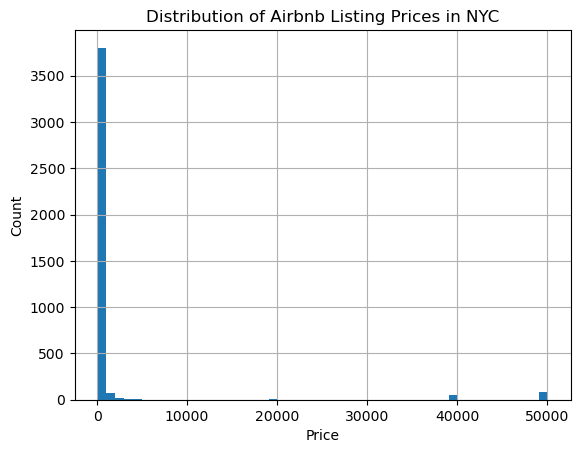

In [13]:
import matplotlib.pyplot as plt 

listings_model["price"].hist(bins=50)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Distribution of Airbnb Listing Prices in NYC")
plt.show()

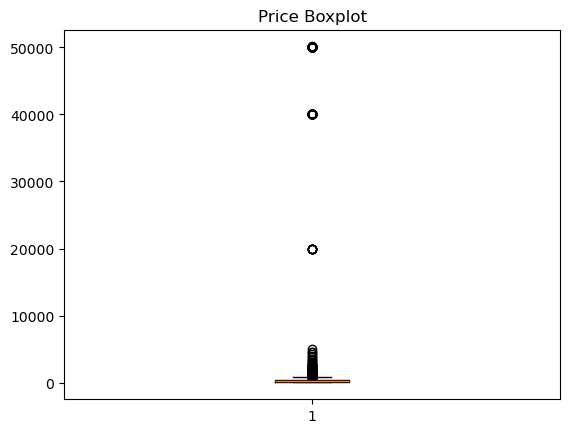

In [14]:
plt.boxplot(listings_model["price"])
plt.title("Price Boxplot")
plt.show()

Price is highly right-skewed with substantial high-end outliers. Most listings are priced below 388 (75% percentile), but a small number of extreme values, including listings near 50,000 per night, greatly increase the mean and standard deviation.

In [15]:
listings_model["room_type"].value_counts()

room_type
Private room       2304
Entire home/apt    1536
Hotel room          164
Shared room          42
Name: count, dtype: int64

Room_type exists hotel room, which is not significant to what I am looking for, let's remove rows that have hotel room listing.

In [16]:
listings_model = listings_model[listings_model["room_type"] != "Hotel room"]

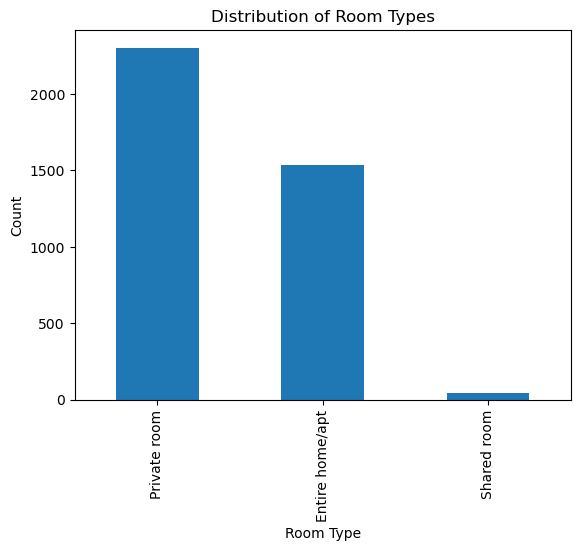

In [17]:
listings_model["room_type"].value_counts().plot(kind="bar")
plt.xlabel("Room Type")
plt.ylabel("Count")
plt.title("Distribution of Room Types")
plt.show()

In [18]:
listings_model.groupby("room_type")["price"].describe().sort_values('count', ascending=False)

,count,mean,std,min,25%,50%,75%,max
room_type,,,,,,,,
Private room,2304.0,384.874566,2185.863943,23.0,110.00,158.0,275.0,50000.0
Entire home/apt,1536.0,455.190755,1659.336312,90.0,205.75,305.0,462.0,50000.0
Shared room,42.0,221.190476,332.058490,68.0,99.50,160.5,222.5,2247.0


In [19]:
listings_model["neighbourhood_group"].value_counts()

neighbourhood_group
Manhattan        1708
Brooklyn         1344
Queens            659
Bronx             120
Staten Island      51
Name: count, dtype: int64

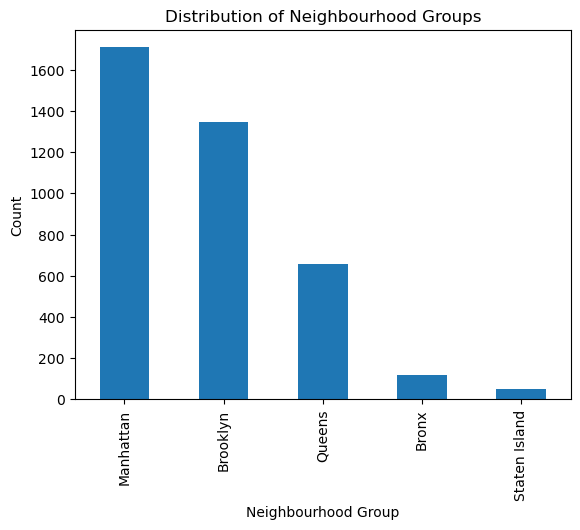

In [20]:
listings_model["neighbourhood_group"].value_counts().plot(kind="bar")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Count")
plt.title("Distribution of Neighbourhood Groups")
plt.show()

In [21]:
listings_model.groupby("neighbourhood_group")["price"].describe().sort_values('count', ascending=False)

,count,mean,std,min,25%,50%,75%,max
neighbourhood_group,,,,,,,,
Manhattan,1708.0,683.932084,2961.066863,62.0,217.0,343.0,520.0,50000.0
Brooklyn,1344.0,219.569940,160.621905,43.0,129.0,173.5,261.0,3109.0
Queens,659.0,163.371775,116.453259,23.0,99.0,128.0,194.5,1582.0
Bronx,120.0,148.933333,86.063562,35.0,93.5,125.0,171.5,391.0
Staten Island,51.0,125.921569,69.259467,53.0,86.5,109.0,142.0,503.0


In [22]:
listings_model.sort_values("price", ascending=False)[
    ["price", "minimum_nights", "room_type", "neighbourhood_group", "neighbourhood"]
].head(20)

,price,minimum_nights,room_type,neighbourhood_group,neighbourhood
29201,50000.0,1,Private room,Manhattan,Midtown
23672,50000.0,1,Private room,Manhattan,Midtown
24025,50000.0,1,Entire home/apt,Manhattan,Murray Hill
28483,40002.0,1,Private room,Manhattan,Murray Hill
23395,40000.0,1,Entire home/apt,Manhattan,Murray Hill
23526,40000.0,1,Private room,Manhattan,Midtown
26095,20000.0,1,Private room,Manhattan,SoHo
26096,20000.0,1,Private room,Manhattan,SoHo
26097,20000.0,1,Private room,Manhattan,SoHo
34081,20000.0,1,Private room,Manhattan,Financial District


Outliers definitely exist here through distribution analysis. Listings with prices above $5,100 were removed, as they represent unrealistic or non-standard entries (e.g., private rooms listed at $20,000–$50,000 per night). These values would disproportionately skew the model and do not reflect typical market behavior.

In [23]:
listings_model["price"].quantile([0.95, 0.975, 0.99, 0.995, 0.9995, 0.9999])

0.9500      826.950
0.9750     1105.975
0.9900     2007.680
0.9950     3475.555
0.9995    50000.000
0.9999    50000.000
Name: price, dtype: float64

In [24]:
upper = listings_model["price"].quantile(0.99)
listings_model = listings_model[listings_model["price"] <= upper]

In [25]:
listings_model.sort_values("price", ascending=False)[
    ["price", "minimum_nights", "room_type", "neighbourhood_group", "neighbourhood"]
].head(20)

,price,minimum_nights,room_type,neighbourhood_group,neighbourhood
27054,1994.0,1,Private room,Manhattan,Midtown
22994,1899.0,1,Entire home/apt,Manhattan,Harlem
15053,1879.0,7,Entire home/apt,Manhattan,Midtown
27053,1862.0,1,Private room,Manhattan,Midtown
14952,1835.0,1,Private room,Manhattan,Midtown
34077,1743.0,1,Private room,Manhattan,Financial District
27052,1737.0,1,Private room,Manhattan,Midtown
27051,1737.0,1,Private room,Manhattan,Midtown
36254,1715.0,1,Private room,Manhattan,Financial District
34006,1711.0,3,Entire home/apt,Manhattan,Harlem


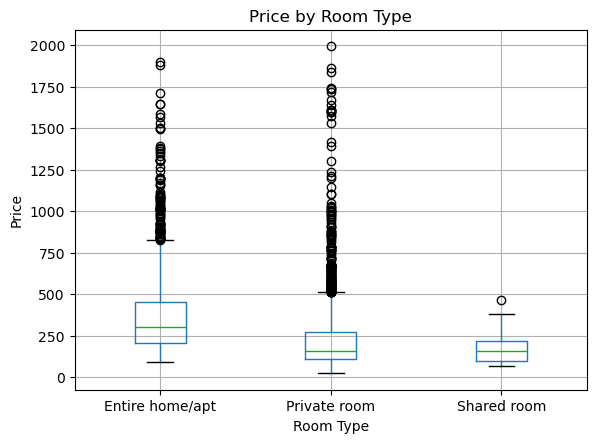

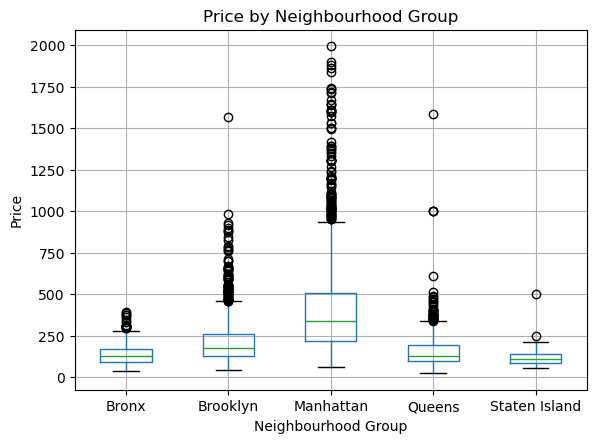

In [26]:
listings_model.boxplot(column="price", by="room_type")
plt.title("Price by Room Type")
plt.suptitle("")
plt.xlabel("Room Type")
plt.ylabel("Price")
plt.show()

listings_model.boxplot(column="price", by="neighbourhood_group")
plt.title("Price by Neighbourhood Group")
plt.suptitle("")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Price")
plt.show()

The price distribution is highly right-skewed, with a dense concentration of listings between $130 and $350 and a long tail of higher-priced listings. The boxplot shows that values above approximately $700 are statistically considered outliers, but many of these still represent plausible high-end listings.

To remove only the most extreme values while preserving meaningful variation, a 99th percentile cutoff (~$1994) was applied. This eliminates the top 1% of listings (e.g., $20,000–$50,000 entries) that would cause noise in model training.

However because distribution is still highly right-skewed, apply log-transformation 

In [27]:
listings_model["log_price"] = np.log1p(listings_model["price"])

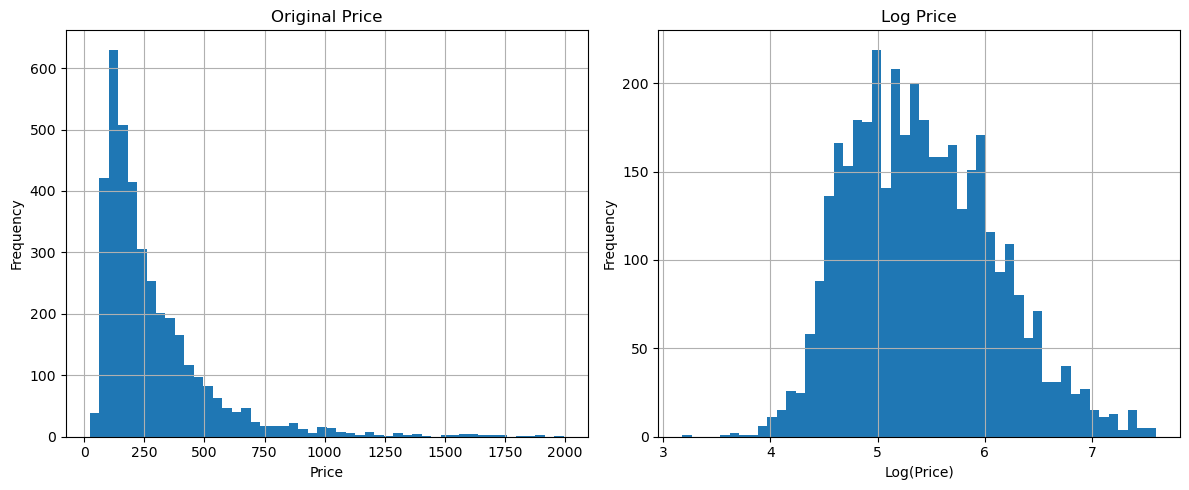

In [28]:
plt.figure(figsize=(12,5))

# Original price
plt.subplot(1, 2, 1)
listings_model["price"].hist(bins=50)
plt.title("Original Price")
plt.xlabel("Price")
plt.ylabel("Frequency")

# Log-transformed price
plt.subplot(1, 2, 2)
listings_model["log_price"].hist(bins=50)
plt.title("Log Price")
plt.xlabel("Log(Price)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

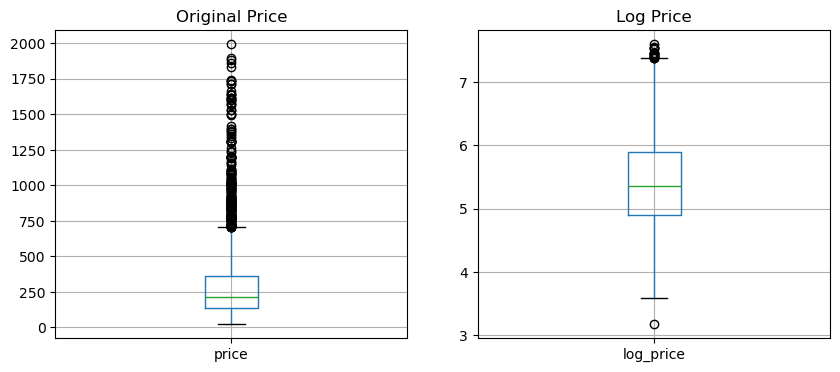

In [29]:
# boxplots for original and log-transformed prices
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
listings_model.boxplot(column="price")
plt.title("Original Price")

plt.subplot(1,2,2)
listings_model.boxplot(column="log_price")
plt.title("Log Price")

plt.show()

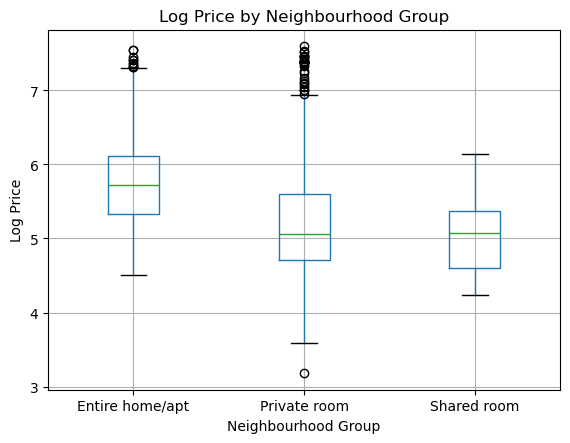

In [30]:
listings_model.boxplot(column="log_price", by="room_type")
plt.title("Log Price by Neighbourhood Group")
plt.suptitle("")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Log Price")
plt.show()

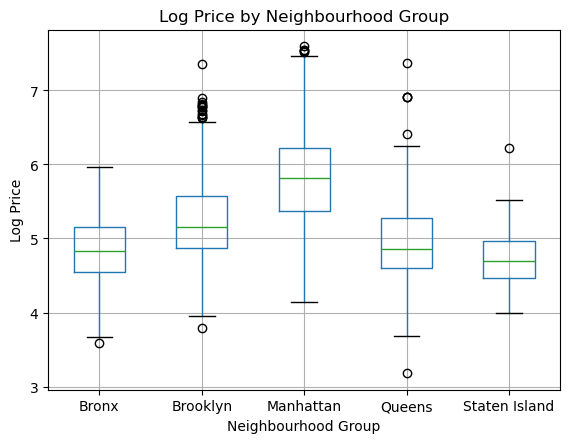

In [31]:
listings_model.boxplot(column="log_price", by="neighbourhood_group")
plt.title("Log Price by Neighbourhood Group")
plt.suptitle("")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Log Price")
plt.show()

In [32]:
# one hot encoding for room_type and neighbourhood_group
listings_model = pd.get_dummies(
    listings_model,
    columns=["room_type", "neighbourhood_group"],
    drop_first=True,
    dtype=int
)

In [33]:
listings_model.head()

,neighbourhood,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,log_price,room_type_Private room,room_type_Shared room,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island
0,Eltingville,40.535470,-74.151350,87.0,2,17,1.62,1,73,17,4.477337,1,0,0,0,0,1
20,Midtown,40.748290,-73.988680,234.0,1,11,0.93,71,148,11,5.459586,1,0,0,1,0,0
21,Midtown,40.746444,-73.988726,131.0,1,10,0.89,71,170,10,4.882802,1,0,0,1,0,0
22,Jackson Heights,40.752620,-73.853990,96.0,3,19,3.22,1,47,19,4.574711,1,0,0,0,1,0
23,Glendale,40.703793,-73.877167,91.0,4,37,3.92,3,356,37,4.521789,1,0,0,0,1,0


# Baseline Model

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X = listings_model.drop(columns=["price", "log_price", "neighbourhood"])
y = listings_model["log_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

mae, rmse, r2


(0.40821399457414237, np.float64(0.5166876194559481), 0.4102635742606737)

In [35]:
pred_price = np.expm1(y_pred)
actual_price = np.expm1(y_test)

mae_price = mean_absolute_error(actual_price, pred_price)
rmse_price = np.sqrt(mean_squared_error(actual_price, pred_price))

mae_price, rmse_price

(117.36730246575779, np.float64(204.96486113777556))

The baseline linear regression model achieved an MAE of 0.408, RMSE of 0.517, and R² of 0.410 on the log-transformed price target. This indicates that the model captures meaningful pricing signal, but still leaves substantial unexplained variance. The results suggest that room type and location provide useful predictive information, while a more flexible nonlinear model may improve performance.

In [36]:
from sklearn.ensemble import RandomForestRegressor  

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

mae_rf, rmse_rf, r2_rf

(0.29884986992689666, np.float64(0.3988697363333846), 0.6485496220259211)

In [37]:
pred_price_rf = np.expm1(y_pred_rf)
actual_price_rf = np.expm1(y_test)

mae_price_rf = mean_absolute_error(actual_price_rf, pred_price_rf)
rmse_price_rf = np.sqrt(mean_squared_error(actual_price_rf, pred_price_rf))

mae_price_rf, rmse_price_rf

(90.47927302637213, np.float64(173.87684918449776))

# Improved Modeling Pipeline

The first Random Forest is useful, but it leaves performance on the table because it drops `neighbourhood`, uses only a single train/test split, evaluates mostly on the log scale, and uses a very basic model configuration.

This section keeps the same project scope, builds model-ready features from the cleaned Airbnb listings, compares stronger sklearn models, evaluates on both log-price and original-dollar scales, and creates an above/below-market residual table.

In [38]:
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42

In [39]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 6371.0 * 2 * np.arcsin(np.sqrt(a))


def build_model_frame(raw_listings, price_quantile=0.99):
    model_df = raw_listings.dropna(subset=["price"]).copy()
    model_df["reviews_per_month"] = model_df["reviews_per_month"].fillna(0)

    last_review_dt = pd.to_datetime(model_df["last_review"], errors="coerce")
    snapshot_date = last_review_dt.max()
    model_df["has_review"] = last_review_dt.notna().astype(int)
    days_since_review = (snapshot_date - last_review_dt).dt.days
    model_df["days_since_last_review"] = days_since_review.fillna(days_since_review.max() + 365)

    model_df = model_df[model_df["license"].notna()].copy()
    model_df = model_df[model_df["minimum_nights"] < 30].copy()
    model_df = model_df[model_df["room_type"] != "Hotel room"].copy()

    price_cap = model_df["price"].quantile(price_quantile)
    model_df = model_df[model_df["price"] <= price_cap].copy()

    model_df["log_price"] = np.log1p(model_df["price"])
    model_df["license_status"] = np.where(model_df["license"].eq("Exempt"), "Exempt", "Registered")
    model_df["room_borough"] = model_df["room_type"].astype(str) + "__" + model_df["neighbourhood_group"].astype(str)
    model_df["room_neighbourhood"] = model_df["room_type"].astype(str) + "__" + model_df["neighbourhood"].astype(str)

    for col in [
        "minimum_nights",
        "number_of_reviews",
        "reviews_per_month",
        "calculated_host_listings_count",
        "availability_365",
        "number_of_reviews_ltm",
        "days_since_last_review",
    ]:
        model_df[f"log1p_{col}"] = np.log1p(model_df[col])

    lat = model_df["latitude"]
    lon = model_df["longitude"]
    model_df["lat_centered"] = lat - lat.mean()
    model_df["lon_centered"] = lon - lon.mean()
    model_df["lat_lon_interaction"] = model_df["lat_centered"] * model_df["lon_centered"]
    model_df["lat_centered_sq"] = model_df["lat_centered"] ** 2
    model_df["lon_centered_sq"] = model_df["lon_centered"] ** 2

    anchors = {
        "times_square": (40.7580, -73.9855),
        "wall_street": (40.7060, -74.0086),
        "central_park": (40.7812, -73.9665),
        "williamsburg": (40.7081, -73.9571),
        "jfk": (40.6413, -73.7781),
    }
    distance_cols = []
    for name, (anchor_lat, anchor_lon) in anchors.items():
        col = f"distance_{name}_km"
        model_df[col] = haversine_km(lat, lon, anchor_lat, anchor_lon)
        distance_cols.append(col)
    model_df["distance_nearest_anchor_km"] = model_df[distance_cols].min(axis=1)

    return model_df, price_cap


model_df, price_cap = build_model_frame(listings, price_quantile=0.99)

pd.Series({
    "model_rows": len(model_df),
    "price_cap_99pct": price_cap,
    "neighbourhood_count": model_df["neighbourhood"].nunique(),
    "room_neighbourhood_count": model_df["room_neighbourhood"].nunique(),
    "median_price": model_df["price"].median(),
    "max_price_after_cap": model_df["price"].max(),
})

model_rows                  3843.00
price_cap_99pct             2007.68
neighbourhood_count          179.00
room_neighbourhood_count     306.00
median_price                 211.00
max_price_after_cap         1994.00
dtype: float64

In [40]:
numeric_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "number_of_reviews_ltm",
    "has_review",
    "days_since_last_review",
    "log1p_minimum_nights",
    "log1p_number_of_reviews",
    "log1p_reviews_per_month",
    "log1p_calculated_host_listings_count",
    "log1p_availability_365",
    "log1p_number_of_reviews_ltm",
    "log1p_days_since_last_review",
    "lat_centered",
    "lon_centered",
    "lat_lon_interaction",
    "lat_centered_sq",
    "lon_centered_sq",
    "distance_times_square_km",
    "distance_wall_street_km",
    "distance_central_park_km",
    "distance_williamsburg_km",
    "distance_jfk_km",
    "distance_nearest_anchor_km",
]

categorical_features = [
    "room_type",
    "neighbourhood_group",
    "neighbourhood",
    "license_status",
    "room_borough",
    "room_neighbourhood",
]

X = model_df[numeric_features + categorical_features].copy()
y = model_df["log_price"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

X.shape, y.shape

((3843, 34), (3843,))

In [41]:
class SmoothedTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, smoothing=40.0):
        self.smoothing = smoothing

    def fit(self, X, y):
        X = pd.DataFrame(X).copy()
        self.columns_ = list(X.columns)
        y = pd.Series(y).reset_index(drop=True)
        self.global_mean_ = float(y.mean())
        self.maps_ = {}

        for col in self.columns_:
            categories = X[col].astype("object").where(X[col].notna(), "__MISSING__").astype(str).reset_index(drop=True)
            stats = pd.DataFrame({"category": categories, "target": y}).groupby("category")["target"].agg(["count", "mean"])
            encoded = (stats["count"] * stats["mean"] + self.smoothing * self.global_mean_) / (stats["count"] + self.smoothing)
            self.maps_[col] = encoded.to_dict()

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        encoded_columns = []

        for col in self.columns_:
            categories = X[col].astype("object").where(X[col].notna(), "__MISSING__").astype(str)
            encoded_columns.append(categories.map(self.maps_[col]).fillna(self.global_mean_).to_numpy())

        return np.column_stack(encoded_columns)

In [42]:
def regression_metrics(y_true_log, y_pred_log):
    y_true_price = np.expm1(y_true_log)
    y_pred_price = np.expm1(y_pred_log)

    return {
        "mae_log": mean_absolute_error(y_true_log, y_pred_log),
        "rmse_log": np.sqrt(mean_squared_error(y_true_log, y_pred_log)),
        "r2_log": r2_score(y_true_log, y_pred_log),
        "mae_price": mean_absolute_error(y_true_price, y_pred_price),
        "median_ae_price": median_absolute_error(y_true_price, y_pred_price),
        "rmse_price": np.sqrt(mean_squared_error(y_true_price, y_pred_price)),
        "r2_price": r2_score(y_true_price, y_pred_price),
    }


def evaluate_holdout(model_name, model):
    fitted_model = clone(model)
    fitted_model.fit(X_train, y_train)
    y_pred = fitted_model.predict(X_test)
    metrics = regression_metrics(y_test, y_pred)
    metrics["model"] = model_name
    return metrics


def evaluate_cv(model_name, model, n_splits=5):
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    rows = []

    for fold, (train_index, test_index) in enumerate(kfold.split(X), start=1):
        fold_model = clone(model)
        fold_model.fit(X.iloc[train_index], y.iloc[train_index])
        fold_pred = fold_model.predict(X.iloc[test_index])
        fold_metrics = regression_metrics(y.iloc[test_index], fold_pred)
        fold_metrics["fold"] = fold
        rows.append(fold_metrics)

    cv_results = pd.DataFrame(rows)
    mean_metrics = cv_results.drop(columns="fold").mean().add_suffix("_mean")
    std_metrics = cv_results.drop(columns="fold").std().add_suffix("_std")
    return pd.concat([pd.Series({"model": model_name}), mean_metrics, std_metrics])

In [43]:
preprocess_ohe_sparse = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore", min_frequency=5), categorical_features),
    ],
    sparse_threshold=0.3,
)

preprocess_ohe_dense = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore", min_frequency=5, sparse_output=False), categorical_features),
    ],
    sparse_threshold=0.0,
)

preprocess_target_encoded = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", numeric_features),
        ("low_cardinality", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["room_type", "neighbourhood_group", "license_status", "room_borough"]),
        ("high_cardinality", SmoothedTargetEncoder(smoothing=40.0), ["neighbourhood", "room_neighbourhood"]),
    ],
    sparse_threshold=0.0,
)

models = {
    "Dummy median": DummyRegressor(strategy="median"),
    "Ridge + OHE": Pipeline([
        ("preprocess", preprocess_ohe_sparse),
        ("scale", StandardScaler(with_mean=False)),
        ("model", Ridge(alpha=10.0)),
    ]),
    "Random Forest tuned + OHE": Pipeline([
        ("preprocess", preprocess_ohe_sparse),
        ("model", RandomForestRegressor(
            n_estimators=500,
            min_samples_leaf=3,
            max_features=0.7,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
    "ExtraTrees + OHE": Pipeline([
        ("preprocess", preprocess_ohe_sparse),
        ("model", ExtraTreesRegressor(
            n_estimators=500,
            min_samples_leaf=2,
            max_features=0.7,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
    "HistGradientBoosting + OHE": Pipeline([
        ("preprocess", preprocess_ohe_dense),
        ("model", HistGradientBoostingRegressor(
            max_iter=500,
            learning_rate=0.035,
            max_leaf_nodes=31,
            l2_regularization=0.03,
            random_state=RANDOM_STATE,
            early_stopping=True,
        )),
    ]),
    "HistGradientBoosting + target encoding": Pipeline([
        ("preprocess", preprocess_target_encoded),
        ("model", HistGradientBoostingRegressor(
            max_iter=500,
            learning_rate=0.035,
            max_leaf_nodes=31,
            l2_regularization=0.03,
            random_state=RANDOM_STATE,
            early_stopping=True,
        )),
    ]),
    "GradientBoosting + target encoding": Pipeline([
        ("preprocess", preprocess_target_encoded),
        ("model", GradientBoostingRegressor(
            n_estimators=500,
            learning_rate=0.035,
            max_depth=3,
            min_samples_leaf=8,
            subsample=0.8,
            random_state=RANDOM_STATE,
        )),
    ]),
}

In [44]:
holdout_results = pd.DataFrame([
    evaluate_holdout(model_name, model)
    for model_name, model in models.items()
]).sort_values("r2_log", ascending=False)

holdout_results[[
    "model",
    "mae_log",
    "rmse_log",
    "r2_log",
    "mae_price",
    "median_ae_price",
    "rmse_price",
    "r2_price",
]].round(4)

,model,mae_log,rmse_log,r2_log,mae_price,median_ae_price,rmse_price,r2_price
3,ExtraTrees + OHE,0.2775,0.3760,0.6877,85.1194,39.4355,163.6892,0.5308
2,Random Forest tuned + OHE,0.2922,0.3875,0.6684,88.0670,43.8954,169.7526,0.4954
4,HistGradientBoosting + OHE,0.3017,0.4010,0.6447,88.6399,45.2529,167.7371,0.5073
5,HistGradientBoosting + target encoding,0.3169,0.4178,0.6144,93.7319,47.4086,174.0538,0.4695
6,GradientBoosting + target encoding,0.3227,0.4246,0.6017,95.9187,48.5542,177.7494,0.4468
1,Ridge + OHE,0.3494,0.4503,0.5522,103.3032,56.0328,188.0733,0.3806
0,Dummy median,0.5422,0.6728,-0.0000,146.1821,89.0000,246.6822,-0.0656


In [45]:
cv_model_names = [
    "Random Forest tuned + OHE",
    "ExtraTrees + OHE",
    "HistGradientBoosting + OHE",
    "HistGradientBoosting + target encoding",
]

cv_results = pd.DataFrame([
    evaluate_cv(model_name, models[model_name], n_splits=5)
    for model_name in cv_model_names
]).sort_values("r2_log_mean", ascending=False)

cv_results[[
    "model",
    "mae_log_mean",
    "rmse_log_mean",
    "r2_log_mean",
    "r2_log_std",
    "mae_price_mean",
    "median_ae_price_mean",
    "rmse_price_mean",
    "r2_price_mean",
    "r2_price_std",
]].round(4)

,model,mae_log_mean,rmse_log_mean,r2_log_mean,r2_log_std,mae_price_mean,median_ae_price_mean,rmse_price_mean,r2_price_mean,r2_price_std
1,ExtraTrees + OHE,0.2698,0.3651,0.7062,0.0181,83.8180,41.3613,154.2082,0.5857,0.0416
0,Random Forest tuned + OHE,0.2810,0.3740,0.6919,0.0165,86.4307,43.8637,159.1155,0.5600,0.0405
2,HistGradientBoosting + OHE,0.2931,0.3850,0.6733,0.0243,89.7287,47.0411,161.4351,0.5475,0.0453
3,HistGradientBoosting + target encoding,0.2997,0.3937,0.6581,0.0295,91.2103,46.8603,163.6211,0.5345,0.0439


In [46]:
best_model_name = "ExtraTrees + OHE"
best_model = clone(models[best_model_name])
best_model.fit(X_train, y_train)

y_pred_log = best_model.predict(X_test)
y_pred_price = np.expm1(y_pred_log)
y_actual_price = np.expm1(y_test)

market_check = X_test.copy()
market_check["actual_price"] = y_actual_price
market_check["predicted_fair_price"] = y_pred_price
market_check["price_difference"] = market_check["actual_price"] - market_check["predicted_fair_price"]
market_check["pct_difference"] = market_check["price_difference"] / market_check["predicted_fair_price"]

market_check["pricing_signal"] = np.select(
    [
        market_check["pct_difference"] >= 0.15,
        market_check["pct_difference"] <= -0.15,
    ],
    ["Above market", "Below market"],
    default="Near market",
)

market_check[[
    "actual_price",
    "predicted_fair_price",
    "price_difference",
    "pct_difference",
    "pricing_signal",
    "room_type",
    "neighbourhood_group",
    "neighbourhood",
]].sort_values("pct_difference", ascending=False).head(15)

,actual_price,predicted_fair_price,price_difference,pct_difference,pricing_signal,room_type,neighbourhood_group,neighbourhood
601,1568.0,208.010741,1359.989259,6.538072,Above market,Entire home/apt,Brooklyn,Bedford-Stuyvesant
34006,1711.0,395.742188,1315.257812,3.323522,Above market,Entire home/apt,Manhattan,Harlem
24674,1098.0,268.750007,829.249993,3.085581,Above market,Entire home/apt,Manhattan,Washington Heights
7779,650.0,184.756635,465.243365,2.518142,Above market,Private room,Brooklyn,Fort Greene
7933,1638.0,467.166914,1170.833086,2.506241,Above market,Private room,Manhattan,Harlem
474,766.0,233.843629,532.156371,2.275693,Above market,Private room,Brooklyn,Boerum Hill
31394,885.0,297.444047,587.555953,1.975350,Above market,Entire home/apt,Brooklyn,Williamsburg
33386,708.0,240.838479,467.161521,1.939730,Above market,Private room,Manhattan,Upper West Side
29913,479.0,169.775864,309.224136,1.821367,Above market,Private room,Manhattan,Chinatown
176,465.0,165.786281,299.213719,1.804816,Above market,Private room,Brooklyn,Bay Ridge


## Modeling Audit Notes

The strongest version in this notebook is the `ExtraTrees + OHE` pipeline. It keeps `neighbourhood`, uses room/location interaction categories, adds transformed review/host/location features, evaluates on log and dollar scales, and uses cross-validation instead of relying on one split.

The target-encoded gradient boosting versions are included as a check, but they do not beat one-hot encoded ExtraTrees on this dataset. The likely reason is that the high-cardinality features are only moderately high-cardinality here, so one-hot encoding preserves useful neighbourhood and room-neighbourhood distinctions without compressing them into a single mean target value.